# Supervised Learning: Memprediksi Klaster Parfum (Random Forest)

Di notebook ini, kita memuat dataset yang sudah diberi label klaster (dari proses **Unsupervised Learning (K-Means)** sebelumnya). Kita akan menggunakan algoritma **Supervised Learning (Random Forest)** untuk memprediksi klaster parfum baru berdasarkan wangi (deskripsi) sajanya. 

Karena *Notes* (resep) juga digunakan untuk membuat klaster sebelumnya, model ini bersifat proksi (mendekati). Dengan memprediksi klasternya berdasarkan deskripsi, kita bisa merekomendasikan *Notes* untuk wangi baru tersebut berdasar pada referensi notes parfum lain di klaster yang sama.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import nltk
from nltk.stem import WordNetLemmatizer
import re

import warnings
warnings.filterwarnings('ignore')

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

## 2. Load Dataset Berlabel Klaster

In [2]:
# Load dataset yang sudah punya kolom 'Cluster_Aroma' dari proses K-Means sebelumnya
df = pd.read_csv('final_perfume_data_with_clusters.csv')

# Mengisi nilai kosong pada Description jika ada
df['Description'] = df['Description'].fillna('')

# Karena data yang kosong pada Notes sudah dihapus di tahap K-Means sebelumnya (Preprocessing), kita tidak perlu dropna lagi
# Namun jika ada fill yang tersisa:
df['Notes'] = df['Notes'].fillna('')

# Lemmatization & Pembersihan Teks
lemmatizer = WordNetLemmatizer()
def preprocess_text(text):
    text = re.sub(r'[^a-zA-Z\s]', ' ', str(text).lower())
    words = [lemmatizer.lemmatize(w) for w in text.split()]
    return " ".join(words)

# Membersihkan fitur Description
df['Description_Clean'] = df['Description'].apply(preprocess_text)

print("Tabel dengan label Cluster (Supervised Target):")
display(df[['Name', 'Description', 'Notes', 'Cluster_Aroma']].head())

Tabel dengan label Cluster (Supervised Target):


,Name,Description,Notes,Cluster_Aroma
0,Tihota Eau de Parfum,"Rapa Nui for sugar, Tihota is, quite simply, ...","Vanilla bean, musks",5
1,Sola Parfum,A tribute to the expanse of space extending f...,"Lavender, Yuzu, Lemongrass, Magnolia, Geraniu...",7
2,Kagiroi Parfum,An aromatic ode to the ancient beauty of Japa...,"Green yuzu, green shikuwasa, sansho seed, cor...",9
3,Velvet Fantasy Eau de Parfum,Velvet Fantasy is a solar fragrance where cit...,"tangerine, pink pepper, black coffee, leat...",5
4,A Blvd. Called Sunset Eau de Parfum,There's no way A Lab On Fire could relocate t...,"Bergamot, almond, violet, jasmine, leather, s...",6


## 3. Setup X (Features) dan Y (Target)

Sekarang `Cluster_Aroma` menjadi target (label) yang diawasi (Supervised). 
Fitur (X) diambil dari kata-kata (TF-IDF) berdasarkan *Description* saja, sehingga ketika kita punya wangi baru (Deskripsi), kita bisa tebak *Notes* nya.

In [3]:
# Custom Stop Words
custom_stop_words = list(ENGLISH_STOP_WORDS.union(['fragrance', 'scent', 'notes', 'parfum', 'perfume']))

# Variabel Independen (X) - menggunakan Description saja
tfidf_supervised = TfidfVectorizer(stop_words=custom_stop_words, max_features=1000)
X = tfidf_supervised.fit_transform(df['Description_Clean'])

# Variabel Dependen / Target (y)
y = df['Cluster_Aroma'].values

# Membagi data menjadi Data Latih (Train) dan Data Uji (Test) - 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Jumlah Data Latih:", X_train.shape[0])
print("Jumlah Data Uji:", X_test.shape[0])

Jumlah Data Latih: 1752
Jumlah Data Uji: 439


## 4. Modeling (Random Forest Classifier)

## Visualisasi Distribusi Fitur dan Target

Menampilkan distribusi dari target label (Cluster_Aroma) dan fitur numerik yang ada.

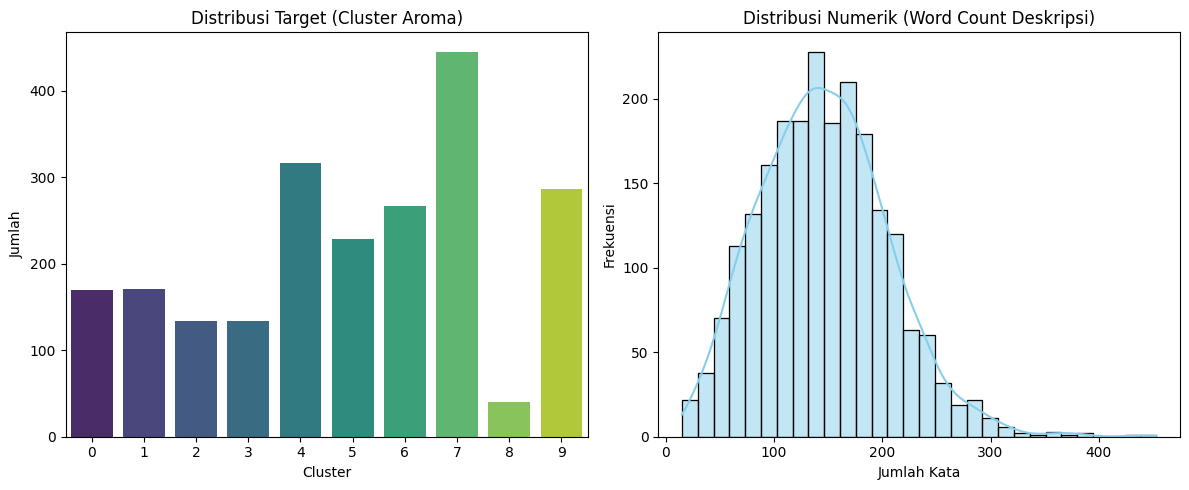

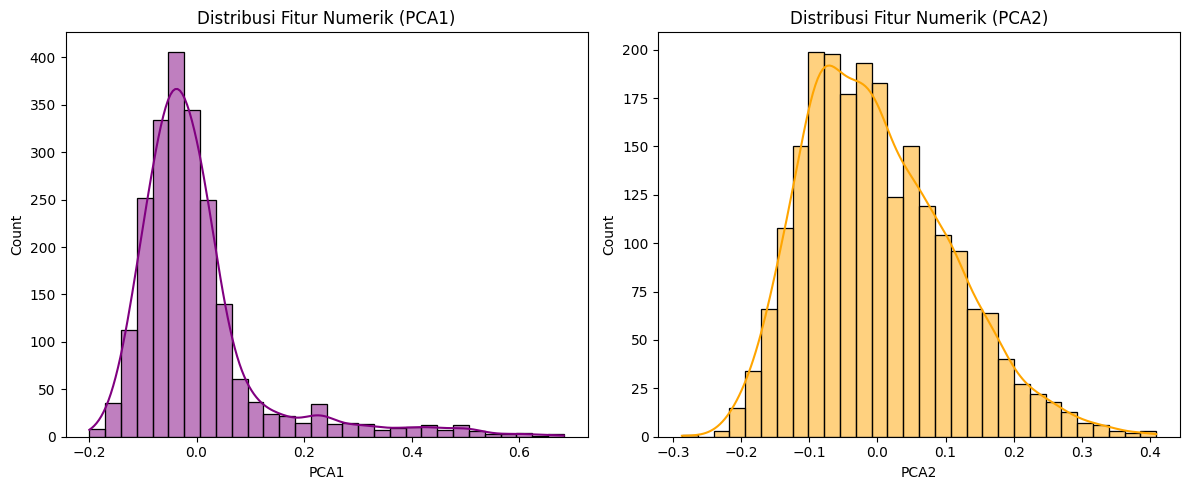

In [4]:
# Distribusi Target (Cluster Aroma)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x=df['Cluster_Aroma'], palette='viridis')
plt.title('Distribusi Target (Cluster Aroma)')
plt.xlabel('Cluster')
plt.ylabel('Jumlah')

# Distribusi Fitur Numerik (Panjang Teks dari Deskripsi)
word_counts = df['Description_Clean'].apply(lambda x: len(x.split()))
plt.subplot(1, 2, 2)
sns.histplot(word_counts, bins=30, kde=True, color='skyblue')
plt.title('Distribusi Numerik (Word Count Deskripsi)')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

# Jika Dataset memiliki fitur bawaan dari PCA sebelumnya
if 'PCA1' in df.columns and 'PCA2' in df.columns:
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df['PCA1'], bins=30, kde=True, color='purple')
    plt.title('Distribusi Fitur Numerik (PCA1)')
    
    plt.subplot(1, 2, 2)
    sns.histplot(df['PCA2'], bins=30, kde=True, color='orange')
    plt.title('Distribusi Fitur Numerik (PCA2)')
    plt.tight_layout()
    plt.show()

In [5]:
# Inisialisasi Classifier dengan class_weight='balanced' untuk mengatasi imbalanced data
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)

# Menggunakan 5-Fold Cross Validation
cv_scores = cross_val_score(rf_base, X_train, y_train, cv=5)
print(f"Rata-rata Akurasi Cross-Validation (5-Fold): {np.mean(cv_scores) * 100:.2f}%\n")

# Hyperparameter Tuning menggunakan GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Gunakan model terbaik dari pencarian hyperparameter
rf_model = grid_search.best_estimator_
print(f"\nParameter Terbaik Random Forest: {grid_search.best_params_}")

# Evaluasi model pada test set
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nAkurasi Model Supervised pada Test Set: {accuracy * 100:.2f}%")

Rata-rata Akurasi Cross-Validation (5-Fold): 72.72%

Fitting 3 folds for each of 27 candidates, totalling 81 fits

Parameter Terbaik Random Forest: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}

Akurasi Model Supervised pada Test Set: 74.94%


## Visualisasi Confusion Matrix

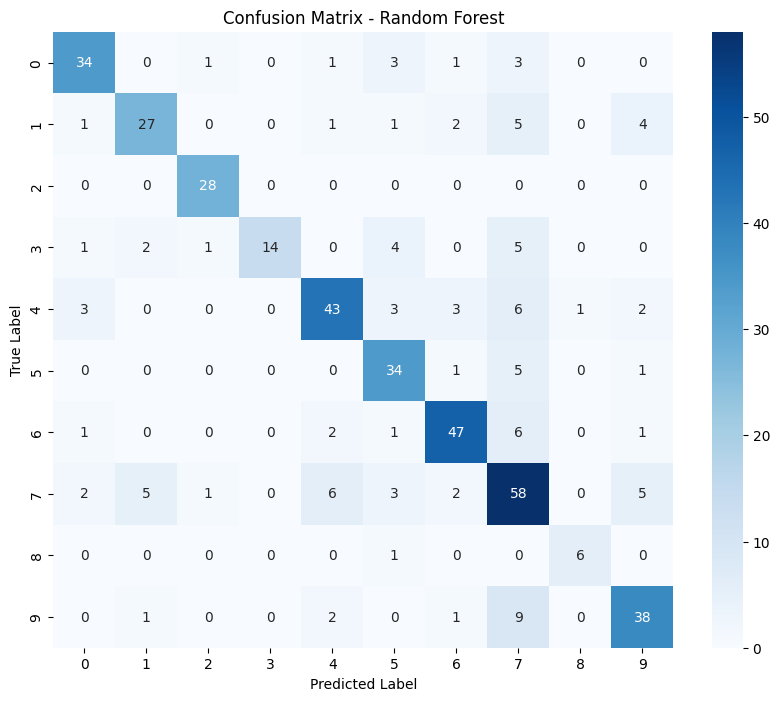

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        43
           1       0.77      0.66      0.71        41
           2       0.90      1.00      0.95        28
           3       1.00      0.52      0.68        27
           4       0.78      0.70      0.74        61
           5       0.68      0.83      0.75        41
           6       0.82      0.81      0.82        58
           7       0.60      0.71      0.65        82
           8       0.86      0.86      0.86         7
           9       0.75      0.75      0.75        51

    accuracy                           0.75       439
   macro avg       0.80      0.76      0.77       439
weighted avg       0.76      0.75      0.75       439



In [6]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

## Feature Importances (Kata Paling Berpengaruh)

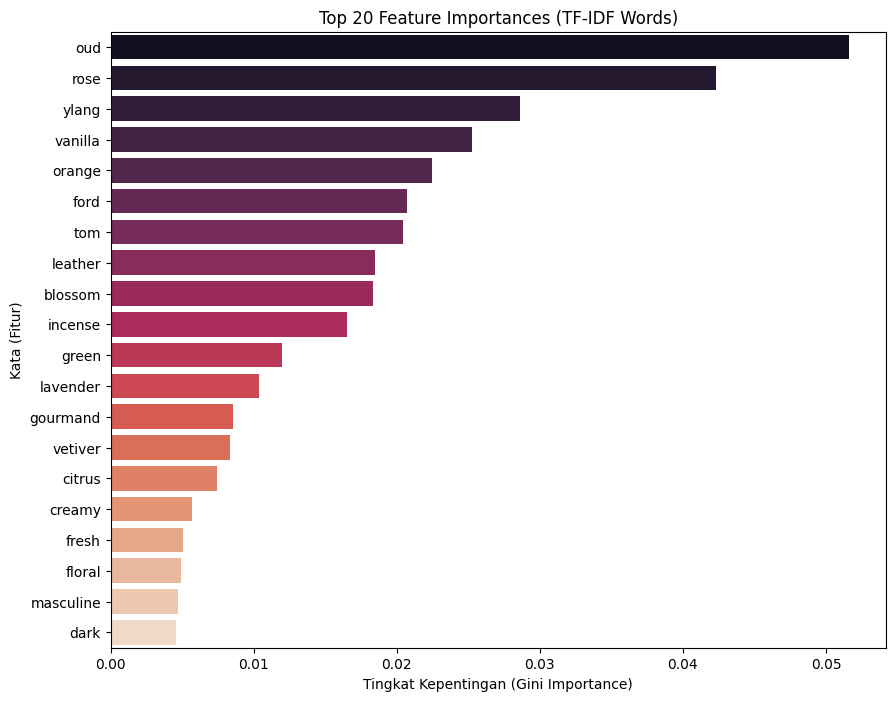

In [7]:
# Mengambil feature importance dari Random Forest Model
importances = rf_model.feature_importances_

# Mengambil nama fitur (kata-kata) dari TF-IDF Vectorizer
feature_names = tfidf_supervised.get_feature_names_out()

# Membuat dataframe untuk memudahkan visualisasi
idx_top20 = np.argsort(importances)[-20:][::-1]
top20_features = feature_names[idx_top20]
top20_importances = importances[idx_top20]

plt.figure(figsize=(10, 8))
sns.barplot(x=top20_importances, y=top20_features, palette='rocket')
plt.title('Top 20 Feature Importances (TF-IDF Words)')
plt.xlabel('Tingkat Kepentingan (Gini Importance)')
plt.ylabel('Kata (Fitur)')
plt.show()

## 5. Simulasi Prediksi Resep

Bagaimana jika kita mendapatkan ringkasan wangi parfum baru yang belum ada resepnya? Kita berikan teks `Description`-nya ke dalam model prediksi!

In [8]:
# Coba wangi baru / deskripsi baru
wangi_baru = "orange"

# Bersihkan teks baru persis seperti data latih
wangi_baru_clean = preprocess_text(wangi_baru)

# Ubah menjadi TF-IDF (gunakan objek text-prep Supervised yang sudah di-fit sebelumnya)
wangi_baru_tfidf = tfidf_supervised.transform([wangi_baru_clean])

# Prediksi klaster
prediksi_klaster = rf_model.predict(wangi_baru_tfidf)[0]
print(f"Teks wangi ini diprediksi masuk ke dalam: Klaster {prediksi_klaster}")

# Kita intip parfum apa saja di Klaster tersebut berdasar data awal
klaster_samples = df[df['Cluster_Aroma'] == prediksi_klaster]

# Gunakan .sample() agar rekomendasi yang muncul bervariasi
n_samples = min(3, len(klaster_samples))

if n_samples > 0:
    sampled_referensi = klaster_samples.sample(n=n_samples, random_state=None)
    
    print("\n--- Referensi Resep Parfum di Klaster Serupa ---")
    for idx, row in sampled_referensi.iterrows():
        print(f"- {row['Name']} (Brand: {row['Brand']})")
        print(f"  Bahan / Resep (Notes): {row['Notes']}\n")
else:
    print("\n--- Tidak ada referensi resep parfum yang tersedia di klaster ini ---")

Teks wangi ini diprediksi masuk ke dalam: Klaster 1

--- Referensi Resep Parfum di Klaster Serupa ---
- Yu Son Eau de Parfum (Brand: ALTAIA)
  Bahan / Resep (Notes):  Mandarin, green tea, jasmine, iris, labdanum, amber, gaiac

- Lavish Parfum (Brand: Boadicea the Victorious)
  Bahan / Resep (Notes):  Bergamot, lemon, orange flower, rose, pepper, nutmeg, sandalwood, cedar, patchouli, gaiac, vetiver, moss, amber

- No.09 Vallee de Farney- Perfume Oil Perfume Oil Roll-On (Brand: Maison Louis Marie)
  Bahan / Resep (Notes):  Grapefruit, orange, black pepper, cedarwood, patchouli, geranium, vetiver, amber, musk, benzoin

